In [1]:
!nvidia-smi

Fri May  1 22:19:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.95                 Driver Version: 581.95         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro T2000                 WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P0             10W /   40W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct

fatal: destination path 'pubmed-rct' already exists and is not an empty directory.
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
!ls pubmed-rct/PubMed_200k_RCT_numbers_replaced_with_at_sign

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
data_dir = "pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [5]:
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt']

In [6]:
def get_lines(filename):
  with open(filename, "r") as f:
    return f.readlines()

In [7]:
train_lines = get_lines(data_dir+"train.txt")
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [8]:

def preprocess_text_with_line_numbers(filename):
  """Returns a list of dictionaries of abstract line data.

  Takes in filename, reads its contents and sorts through each line,
  extracting things like the target label, the text of the sentence,
  how many sentences are in the current abstract and what sentence number
  the target line is.

  Args:
      filename: a string of the target text file to read and extract line data
      from.

  Returns:
      A list of dictionaries each containing a line from an abstract,
      the lines label, the lines position in the abstract and the total number
      of lines in the abstract where the line is from. For example:

      [{"target": 'CONCLUSION',
        "text": The study couldn't have gone better, turns out people are kinder
        than you think",
        "line_number": 8,
        "total_lines": 8}]
  """
  input_lines = get_lines(filename) # get all lines from filename
  abstract_lines = "" # create an empty abstract
  abstract_samples = [] # create an empty list of abstracts

  # Loop through each line in target file
  for line in input_lines:
    if line.startswith("###"): # check to see if line is an ID line
      abstract_id = line
      abstract_lines = "" # reset abstract string
    elif line.isspace(): # check to see if line is a new line
      abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines

      # Iterate through each line in abstract and count them at the same time
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # create empty dict to store data from line
        target_text_split = abstract_line.split("\t") # split target label from text
        line_data["target"] = target_text_split[0] # get target label
        line_data["text"] = target_text_split[1].lower() # get target text and lower it
        line_data["line_number"] = abstract_line_number # what number line does the line appear in the abstract?
        line_data["total_lines"] = len(abstract_line_split) - 1 # how many total lines are in the abstract? (start from 0)
        abstract_samples.append(line_data) # add line data to abstract samples list

    else: # if the above conditions aren't fulfilled, the line contains a labelled sentence
      abstract_lines += line

  return abstract_samples

In [9]:
%%time
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "dev.txt") # dev is another name for validation set
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")
len(train_samples), len(val_samples), len(test_samples)

CPU times: total: 1.05 s
Wall time: 1.05 s


(180040, 30212, 30135)

In [10]:
train_samples[:14]


[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [11]:
import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(14)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [12]:
train_df.target.value_counts()

target
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64

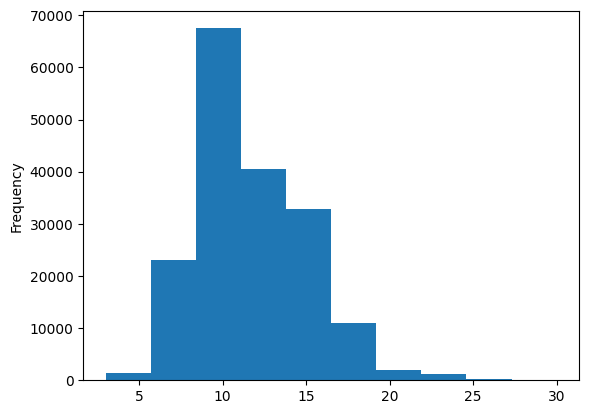

In [13]:
train_df.total_lines.plot.hist();

In [14]:
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)


(180040, 30212, 30135)

In [15]:
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

In [16]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))

train_labels_one_hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180040 stored elements and shape (180040, 5)>

In [17]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

# Check what training labels look like
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1], shape=(180040,))

In [18]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

In [19]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Model 0

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create a pipeline
model_0 = Pipeline([
  ("tf-idf", TfidfVectorizer()),
  ("clf", MultinomialNB())
])

# Fit the pipeline to the training data
model_0.fit(X=train_sentences,
            y=train_labels_encoded);

In [21]:
model_0.score(X=val_sentences, y=val_labels_encoded)

0.7218323844829869

In [22]:
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1], shape=(30212,))

In [23]:
# ✅ FIX: Using Python download instead of wget (wget doesn't exist on Windows)
import urllib.request, os

if not os.path.exists('helper_functions.py'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py',
        'helper_functions.py'
    )
    print('helper_functions.py downloaded!')
else:
    print('helper_functions.py already exists, skipping download.')


helper_functions.py downloaded!


In [24]:
from helper_functions import calculate_results


In [25]:
baseline_results = calculate_results(y_true=val_labels_encoded,
                                     y_pred=baseline_preds)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [27]:
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len

np.float64(26.338269273494777)

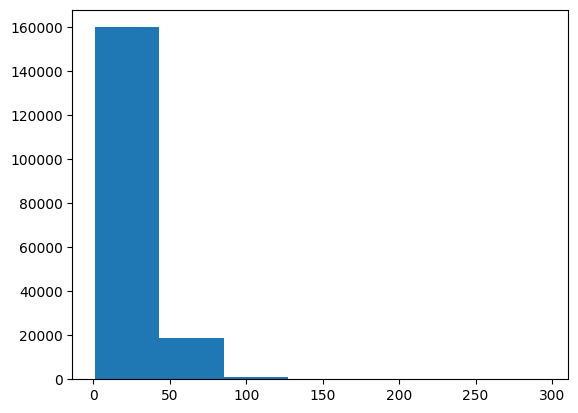

In [28]:
import matplotlib.pyplot as plt
plt.hist(sent_lens, bins=7);

In [29]:
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

55

In [30]:
max(sent_lens)


296

In [31]:
max_tokens = 68000

In [32]:
from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens=max_tokens,
                                    output_sequence_length=55)

In [33]:
text_vectorizer.adapt(train_sentences)


In [34]:
import random
target_sentence = random.choice(train_sentences)
print(f"Text:\n{target_sentence}")
print(f"\nLength of text: {len(target_sentence.split())}")
print(f"\nVectorized text:\n{text_vectorizer([target_sentence])}")

Text:
the delivery of personal genomic risk through a trained health professional resulted in significantly higher comprehension .

Length of text: 17

Vectorized text:
[[   2  479    4 2033 8071   73  313    8 1344   97 2285  568    5   39
    82 5585    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [35]:
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in vocabulary: {len(rct_20k_text_vocab)}"),
print(f"Most common words in the vocabulary: {rct_20k_text_vocab[:5]}")
print(f"Least common words in the vocabulary: {rct_20k_text_vocab[-5:]}")

Number of words in vocabulary: 64841
Most common words in the vocabulary: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of')]
Least common words in the vocabulary: [np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


In [36]:
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

In [37]:
token_embed = layers.Embedding(input_dim=len(rct_20k_text_vocab), # length of vocabulary
                               output_dim=128, # Note: different embedding sizes result in drastically different numbers of parameters to train
                               # Use masking to handle variable sequence lengths (save space)
                               mask_zero=True,
                               name="token_embedding")

print(f"Sentence before vectorization:\n{target_sentence}\n")
vectorized_sentence = text_vectorizer([target_sentence])
print(f"Sentence after vectorization (before embedding):\n{vectorized_sentence}\n")
embedded_sentence = token_embed(vectorized_sentence)
print(f"Sentence after embedding:\n{embedded_sentence}\n")
print(f"Embedded sentence shape: {embedded_sentence.shape}")

Sentence before vectorization:
the delivery of personal genomic risk through a trained health professional resulted in significantly higher comprehension .

Sentence after vectorization (before embedding):
[[   2  479    4 2033 8071   73  313    8 1344   97 2285  568    5   39
    82 5585    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]

Sentence after embedding:
[[[ 0.01133214 -0.01454053  0.01794559 ...  0.0363147  -0.00497399
    0.00783125]
  [-0.02338674  0.04376162 -0.01993208 ...  0.02330567 -0.0204378
    0.01794311]
  [ 0.02215249 -0.01066557 -0.00206792 ...  0.0464384  -0.03501632
   -0.04716305]
  ...
  [ 0.02627439 -0.00127415 -0.00645369 ... -0.03011516 -0.02660254
   -0.02744308]
  [ 0.02627439 -0.00127415 -0.00645369 ... -0.03011516 -0.02660254
   -0.02744308]
  [ 0.02627439 -0.00127415 -0.00645369 ... -0.03011516 -0.0266

In [38]:
import numpy as np

# ✅ FIX: Convert sparse labels to float32 numpy arrays BEFORE creating tf.data datasets
# Passing .toarray() directly causes a DataTypeCanUseMemcpy XLA crash with string tensors
train_labels_dense = np.array(train_labels_one_hot.toarray(), dtype=np.float32)
val_labels_dense   = np.array(val_labels_one_hot.toarray(),   dtype=np.float32)
test_labels_dense  = np.array(test_labels_one_hot.toarray(),  dtype=np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_dense))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences,   val_labels_dense))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_sentences,  test_labels_dense))

train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_dataset


<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [39]:
# Batching is already done in the cell above — this cell is no longer needed
# (kept here to avoid shifting cell numbers downstream)
train_dataset  # just verify the dataset exists


<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [40]:
inputs = layers.Input(shape=(1,), dtype=tf.string)
text_vectors = text_vectorizer(inputs) # vectorize text inputs
token_embeddings = token_embed(text_vectors) # create embedding
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(token_embeddings)
x = layers.GlobalAveragePooling1D()(x) # condense the output of our feature vector
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_1 = tf.keras.Model(inputs, outputs)

# Compile
model_1.compile(loss="categorical_crossentropy", # if your labels are integer form (not one hot) use sparse_categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

c:\Users\Nistha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [41]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_1_history = model_1.fit(train_dataset,
                              steps_per_epoch=int(0.1 * len(train_dataset)),
                              epochs=3,
                              validation_data=valid_dataset,
                              validation_steps=int(0.1 * len(valid_dataset)))

Epoch 1/3


562/562 ━━━━━━━━━━━━━━━━━━━━ 44s 73ms/step - accuracy: 0.6307 - loss: 0.9278 - val_accuracy: 0.7340 - val_loss: 0.7063
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.7516 - loss: 0.6712 - val_accuracy: 0.7650 - val_loss: 0.6467
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.7739 - loss: 0.6225 - val_accuracy: 0.7866 - val_loss: 0.6031


In [43]:
model_1.evaluate(valid_dataset)


  1/945 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.4688 - loss: 0.9083

945/945 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7860 - loss: 0.6008


[0.6008448600769043, 0.7859790921211243]

In [44]:
model_1_pred_probs = model_1.predict(valid_dataset)
model_1_pred_probs


945/945 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


array([[4.4111907e-01, 1.5468046e-01, 9.9270485e-02, 2.7231646e-01,
        3.2613546e-02],
       [3.8635251e-01, 3.4055176e-01, 7.1035018e-03, 2.5922561e-01,
        6.7665754e-03],
       [1.6830976e-01, 1.0938585e-02, 2.6648187e-03, 8.1803691e-01,
        4.9920582e-05],
       ...,
       [4.7778403e-06, 6.8397779e-04, 7.0425461e-04, 2.0741102e-06,
        9.9860495e-01],
       [4.2995803e-02, 4.9078453e-01, 8.5827641e-02, 4.8966512e-02,
        3.3142552e-01],
       [2.3001683e-01, 5.6355613e-01, 5.2428190e-02, 8.2558997e-02,
        7.1439847e-02]], shape=(30212, 5), dtype=float32)

In [45]:
model_1_preds = tf.argmax(model_1_pred_probs, axis=1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1], shape=(30212,))>

In [46]:
model_1_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_1_preds)
model_1_results

{'accuracy': 78.5979081159804,
 'precision': 0.7828111670575155,
 'recall': 0.7859790811598041,
 'f1': 0.7833855103681352}

In [47]:
import tensorflow_hub as hub
tf_hub_embedding_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                        trainable=False,
                                        name="universal_sentence_encoder")

In [48]:
random_training_sentence = random.choice(train_sentences)
print(f"Random training sentence:\n{random_training_sentence}\n")
use_embedded_sentence = tf_hub_embedding_layer([random_training_sentence])
print(f"Sentence after embedding:\n{use_embedded_sentence[0][:30]} (truncated output)...\n")
print(f"Length of sentence embedding:\n{len(use_embedded_sentence[0])}")

Random training sentence:
routine pcs care was provided in specialized clinics .




Sentence after embedding:
[-0.04939848  0.08387025 -0.0257939   0.02590826  0.01212629 -0.0327208
  0.02846461 -0.04005629 -0.0683819  -0.05357657  0.08921659  0.02381882
 -0.07361741 -0.00921653  0.02465144 -0.05885168 -0.09457589  0.08359524
 -0.02832205 -0.02703813 -0.00264111  0.07082981 -0.02994663 -0.07280485
  0.03257137  0.00022251 -0.02685648  0.03775215 -0.00330101 -0.04922928] (truncated output)...

Length of sentence embedding:
512


In [49]:
# ✅ Clear GPU memory from model_0 and model_1 before building model_2
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()
print('Memory cleared. Ready to build model_2.')

Memory cleared. Ready to build model_2.


In [50]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_hub as hub

# Define the TensorFlow Hub embedding layer (re-added for self-containment)
tf_hub_embedding_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                        trainable=False,
                                        name="universal_sentence_encoder")

# Define a custom Keras Layer to wrap the TensorFlow Hub KerasLayer
# This helps resolve issues where hub.KerasLayer might not correctly handle
# symbolic KerasTensors during graph construction in specific TensorFlow versions or contexts.
class UniversalSentenceEncoderWrapper(layers.Layer):
    def __init__(self, hub_layer, **kwargs):
        super().__init__(**kwargs)
        self.encoder = hub_layer

    @tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.string)])
    def call(self, inputs):
        return self.encoder(inputs)

inputs = layers.Input(shape=[], dtype=tf.string)

# Use the custom wrapper layer to pass the tf_hub_embedding_layer
pretrained_embedding = UniversalSentenceEncoderWrapper(tf_hub_embedding_layer)(inputs)

x = layers.Dense(128, activation="relu")(pretrained_embedding)
outputs = layers.Dense(num_classes, activation="softmax")(x) # num_classes is 5 from previous cells
model_2 = tf.keras.Model(inputs=inputs,
                        outputs=outputs)

# Compile the model
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [51]:
model_2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ universal_sentence_encoder_wra… │ (None, 512)            │             0 │
│ (UniversalSentenceEncoderWrapp… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,309 (259.02 KB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# ✅ Datasets already created above with float32 labels — just re-batch for model_2
# (train_labels_dense and val_labels_dense already exist from cell 38)

BATCH_SIZE = 32

train_dataset_batched = tf.data.Dataset.from_tensor_slices(
    (train_sentences, train_labels_dense)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_dataset_batched = tf.data.Dataset.from_tensor_slices(
    (val_sentences, val_labels_dense)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

model_2_history = model_2.fit(
    train_dataset_batched,
    epochs=3,
    validation_data=valid_dataset_batched
)


Epoch 1/3
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 125s 21ms/step - accuracy: 0.7215 - loss: 0.7294 - val_accuracy: 0.7487 - val_loss: 0.6564
Epoch 2/3
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 125s 22ms/step - accuracy: 0.7584 - loss: 0.6364 - val_accuracy: 0.7617 - val_loss: 0.6211
Epoch 3/3
5627/5627 ━━━━━━━━━━━━━━━━━━━━ 117s 21ms/step - accuracy: 0.7722 - loss: 0.6013 - val_accuracy: 0.7683 - val_loss: 0.6055


In [53]:
model_2.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7683 - loss: 0.6055


[0.6055288910865784, 0.768337070941925]

In [54]:
model_2_pred_probs = model_2.predict(valid_dataset)
model_2_pred_probs
     

945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step


array([[4.9995130e-01, 3.8190013e-01, 1.8908799e-04, 1.1584696e-01,
        2.1125011e-03],
       [4.1652313e-01, 4.8827305e-01, 8.2916522e-04, 9.3593389e-02,
        7.8134850e-04],
       [5.8821332e-01, 1.0814095e-02, 1.3877304e-02, 3.7745163e-01,
        9.6436115e-03],
       ...,
       [4.5757747e-04, 5.1196024e-04, 1.7029949e-02, 1.5541218e-04,
        9.8184514e-01],
       [1.1805288e-02, 1.6385032e-01, 1.4953908e-01, 3.0651116e-03,
        6.7174023e-01],
       [1.2366617e-02, 9.8271692e-01, 4.5764819e-03, 3.8619335e-05,
        3.0131446e-04]], shape=(30212, 5), dtype=float32)

In [55]:
model_2_preds = tf.argmax(model_2_pred_probs, axis=1)
model_2_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 0, ..., 4, 4, 1], shape=(30212,))>

In [56]:
model_2_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_2_preds)
model_2_results

{'accuracy': 76.8337084602145,
 'precision': 0.7659457790505018,
 'recall': 0.7683370846021449,
 'f1': 0.764102998946316}

## Model 3

In [57]:
def split_chars(text):
  return " ".join(list(text))

# Test splitting non-character-level sequence into characters
split_chars(random_training_sentence)

'r o u t i n e   p c s   c a r e   w a s   p r o v i d e d   i n   s p e c i a l i z e d   c l i n i c s   .'

In [58]:
train_chars = [split_chars(sentence) for sentence in train_sentences]
val_chars = [split_chars(sentence) for sentence in val_sentences]
test_chars = [split_chars(sentence) for sentence in test_sentences]
print(train_chars[0])

t o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .


In [59]:
char_lens = [len(sentence) for sentence in train_sentences]
mean_char_len = np.mean(char_lens)
mean_char_len
     

np.float64(149.3662574983337)

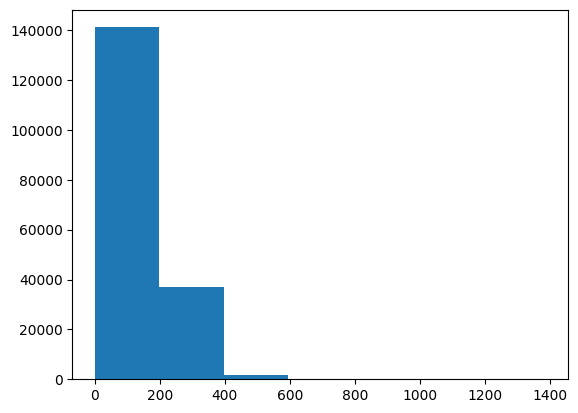

In [60]:
import matplotlib.pyplot as plt
plt.hist(char_lens, bins=7);

In [61]:
output_seq_char_len = int(np.percentile(char_lens, 95))
output_seq_char_len

290

In [62]:
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [63]:
NUM_CHAR_TOKENS = len(alphabet) + 2 # num characters in alphabet + space + OOV token
char_vectorizer = TextVectorization(max_tokens=NUM_CHAR_TOKENS,  
                                    output_sequence_length=output_seq_char_len,
                                    standardize="lower_and_strip_punctuation",
                                    name="char_vectorizer")

# Adapt character vectorizer to training characters
char_vectorizer.adapt(train_chars)

In [64]:
char_vocab = char_vectorizer.get_vocabulary()
print(f"Number of different characters in character vocab: {len(char_vocab)}")
print(f"5 most common characters: {char_vocab[:5]}")
print(f"5 least common characters: {char_vocab[-5:]}")

Number of different characters in character vocab: 28
5 most common characters: ['', '[UNK]', np.str_('e'), np.str_('t'), np.str_('i')]
5 least common characters: [np.str_('k'), np.str_('x'), np.str_('z'), np.str_('q'), np.str_('j')]


In [65]:
random_train_chars = random.choice(train_chars)
print(f"Charified text:\n{random_train_chars}")
print(f"\nLength of chars: {len(random_train_chars.split())}")
vectorized_chars = char_vectorizer([random_train_chars])
print(f"\nVectorized chars:\n{vectorized_chars}")
print(f"\nLength of vectorized chars: {len(vectorized_chars[0])}")

Charified text:
m a j o r   i m p r o v e m e n t s   i n   t h e   i m p l e m e n t a t i o n   o f   ` `   t e s t   a n d   t r e a t   ' '   p o l i c y   w e r e   o b s e r v e d   i n   k e n y a   .

Length of chars: 80

Vectorized chars:
[[15  5 27  7  8  4 15 14  8  7 21  2 15  2  6  3  9  4  6  3 13  2  4 15
  14 12  2 15  2  6  3  5  3  4  7  6  7 17  3  2  9  3  5  6 10  3  8  2
   5  3 14  7 12  4 11 19 20  2  8  2  7 22  9  2  8 21  2 10  4  6 23  2
   6 19  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  

In [66]:
char_embed = layers.Embedding(input_dim=NUM_CHAR_TOKENS, # number of different characters
                              output_dim=25, # embedding dimension of each character (same as Figure 1 in https://arxiv.org/pdf/1612.05251.pdf)
                              mask_zero=False, # don't use masks (this messes up model_5 if set to True)
                              name="char_embed")

# Test out character embedding layer
print(f"Charified text (before vectorization and embedding):\n{random_train_chars}\n")
char_embed_example = char_embed(char_vectorizer([random_train_chars]))
print(f"Embedded chars (after vectorization and embedding):\n{char_embed_example}\n")
print(f"Character embedding shape: {char_embed_example.shape}")
     

Charified text (before vectorization and embedding):
m a j o r   i m p r o v e m e n t s   i n   t h e   i m p l e m e n t a t i o n   o f   ` `   t e s t   a n d   t r e a t   ' '   p o l i c y   w e r e   o b s e r v e d   i n   k e n y a   .

Embedded chars (after vectorization and embedding):
[[[-0.00524702  0.04093286  0.01951004 ...  0.03217763 -0.00367504
    0.02933962]
  [ 0.03830167 -0.00457913  0.04270731 ...  0.0476259   0.01026605
    0.01062   ]
  [ 0.04673704  0.03676636 -0.00589315 ... -0.01992874 -0.03604025
    0.02125773]
  ...
  [ 0.03165902 -0.01586913  0.02280942 ... -0.00813871  0.03667039
   -0.04490272]
  [ 0.03165902 -0.01586913  0.02280942 ... -0.00813871  0.03667039
   -0.04490272]
  [ 0.03165902 -0.01586913  0.02280942 ... -0.00813871  0.03667039
   -0.04490272]]]

Character embedding shape: (1, 290, 25)


In [67]:
inputs = layers.Input(shape=(1,), dtype="string")
char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(char_embeddings)
x = layers.GlobalMaxPool1D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_3 = tf.keras.Model(inputs=inputs,
                         outputs=outputs,
                         name="model_3_conv1D_char_embedding")

# Compile model
model_3.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [68]:
model_3.summary()

Model: "model_3_conv1D_char_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_vectorizer                 │ (None, 290)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embed (Embedding)          │ (None, 290, 25)        │         1,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 290, 64)        │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,139 (39.61 KB)

 Trainable params: 10,139 (39.61 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars, train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset = tf.data.Dataset.from_tensor_slices((val_chars, val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

train_char_dataset

ValueError: TypeError: sparse array length is ambiguous; use getnnz() or shape[0]
Traceback (most recent call last):

  File "c:\Users\Nistha\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\data\util\structure.py", line 105, in normalize_element
    spec = type_spec_from_value(t, use_fallback=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "c:\Users\Nistha\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\data\util\structure.py", line 514, in type_spec_from_value
    raise TypeError("Could not build a `TypeSpec` for {} with type {}".format(

TypeError: Could not build a `TypeSpec` for <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180040 stored elements and shape (180040, 5)>
  Coords	Values
  (0, 3)	1.0
  (1, 2)	1.0
  (2, 2)	1.0
  (3, 2)	1.0
  (4, 2)	1.0
  (5, 2)	1.0
  (6, 4)	1.0
  (7, 4)	1.0
  (8, 4)	1.0
  (9, 4)	1.0
  (10, 4)	1.0
  (11, 1)	1.0
  (12, 0)	1.0
  (13, 0)	1.0
  (14, 3)	1.0
  (15, 3